In [2]:
import pandas as pd

# Load both CSVs
df_spont = pd.read_csv("./labels-features/spontanaktivität.csv")
df_norm = pd.read_csv("./labels-features/normal.csv")

# Downsample 'Normal' to 2000 samples to balance the dataset
desired_normal_n = 2000
if len(df_norm) > desired_normal_n:
    df_norm = df_norm.sample(n=desired_normal_n, random_state=42).reset_index(drop=True)

# Combine them
df = pd.concat([df_spont, df_norm], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples after downsampling Normal to 2000:", len(df))
print("Columns:", df.columns.tolist())
print(df['Label'].value_counts())

Total samples after downsampling Normal to 2000: 4324
Columns: ['File', 'Label', 'Start Sample', 'End Sample', 'Duration', 'Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7']
Label
Normal          2000
PSW             1849
Fibrillation     475
Name: count, dtype: int64


In [3]:
feature_cols = [col for col in df.columns if col.startswith("Feature_")]

X = df[feature_cols].values
y = df["Label"].values
# Keep a positional index array so we can map test splits back to the dataframe rows
idx = df.index.values

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split

# First split train/test and propagate indices
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_scaled, y_encoded, idx, test_size=0.3, stratify=y_encoded, random_state=42
)

# Then split temp into validation/test
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 3026, Val: 649, Test: 649


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


Validation Results:
              precision    recall  f1-score   support

Fibrillation       0.76      0.83      0.79        71
      Normal       0.86      0.77      0.81       300
         PSW       0.78      0.86      0.82       278

    accuracy                           0.81       649
   macro avg       0.80      0.82      0.81       649
weighted avg       0.82      0.81      0.81       649


Test Results:
              precision    recall  f1-score   support

Fibrillation       0.77      0.83      0.80        72
      Normal       0.83      0.81      0.82       300
         PSW       0.80      0.81      0.81       277

    accuracy                           0.81       649
   macro avg       0.80      0.82      0.81       649
weighted avg       0.81      0.81      0.81       649



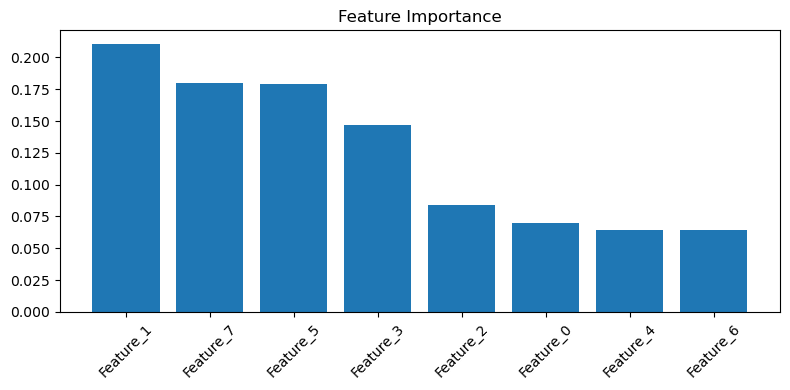

In [7]:
import matplotlib.pyplot as plt
import numpy as np

print("\nValidation Results:")
print(classification_report(y_val, clf.predict(X_val), target_names=encoder.classes_))

print("\nTest Results:")
print(classification_report(y_test, clf.predict(X_test), target_names=encoder.classes_))

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,4))
plt.title("Feature Importance")
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feature_cols[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [8]:
import os
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
LOWCUT, HIGHCUT = 20, 500   # Hz
PSW_THRESH_UV = 200          # µV
FIB_THRESH_UV = 10           # µV
ADC_SCALE = 32768            # 16-bit full scale
FULL_SCALE_UV = 800          # µV (±10 mV assumed)

def plot_single(file_path, start_ms=None, end_ms=None, true_label=None, predicted_label=None, row=None):
    try:
        # ---------- LOAD ----------
        fs, data = wavfile.read(file_path)
        if data.ndim > 1:
            data = np.mean(data, axis=1)

        # Convert to µV
        signal_uV = (data / ADC_SCALE) * FULL_SCALE_UV

        # ---------- FILTER ----------
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low, high = lowcut / nyq, highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a

        b, a = butter_bandpass(LOWCUT, HIGHCUT, fs)
        filtered = filtfilt(b, a, signal_uV)

        # ---------- DETECT THRESHOLD CROSSES ----------
        def detect_regions(signal, threshold):
            above = np.abs(signal) >= threshold
            regions = []
            in_region, start = False, None
            for i, val in enumerate(above):
                if val and not in_region:
                    in_region, start = True, i
                elif not val and in_region:
                    in_region = False
                    regions.append((start, i))
            if in_region:
                regions.append((start, len(signal)))
            return regions

        regions = detect_regions(filtered, PSW_THRESH_UV)

        # ---------- TIME AXIS ----------
        t = np.arange(len(filtered)) / fs * 1000  # ms

        # ---------- PLOT ----------
        fig, ax = plt.subplots(figsize=(20, 6))
        ax.plot(t, filtered, color='black', linewidth=1, label='Filtered EMG (µV)')

        # Determine time range
        x_min = start_ms if start_ms is not None else 0
        x_max = end_ms if end_ms is not None else t[-1]
        ax.set_xlim([x_min, x_max])

        # Horizontal PSW / FIB lines
        for y in [PSW_THRESH_UV, -PSW_THRESH_UV, FIB_THRESH_UV, -FIB_THRESH_UV]:
            color = 'red' if abs(y) == PSW_THRESH_UV else 'blue'
            ax.axhline(y=y, color=color, linestyle='--', linewidth=1)
            ax.text(x_max, y, f"{y:+.0f} µV", color=color,
                    verticalalignment='bottom' if y > 0 else 'top',
                    horizontalalignment='right')

        # Highlight threshold regions
        for start, end in regions:
            ax.axvspan(t[start], t[end], color='red', alpha=0.15)

        # Get y-axis limits for placing text labels
        y_min, y_max = ax.get_ylim()
        y_mid = (y_min + y_max) / 2

        # Grid: major every 1 s (1000 ms) - starting from x_min
        major_start = int(np.ceil(x_min / 1000) * 1000)
        major_ticks = np.arange(major_start, x_max + 1, 1000)
        ax.set_xticks(major_ticks)
        
        # Grid: minor every 10 ms (darker) - starting from x_min
        minor_start = int(np.ceil(x_min / 10) * 10)
        minor_ticks = np.arange(minor_start, x_max + 1, 10)
        ax.set_xticks(minor_ticks, minor=True)
        
        ax.grid(which='major', color='black', linestyle='-', linewidth=1, alpha=0.7)
        ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.6, alpha=0.5)  # darker and solid

        # Add text labels for 10ms grid lines
        for x_pos in minor_ticks:
            if x_min < x_pos <= x_max:  # only show labels within visible range
                ax.text(x_pos, y_mid, f'{int(x_pos)}', 
                       rotation=90, verticalalignment='center', 
                       horizontalalignment='right',
                       fontsize=7, color='grey', alpha=0.7)

        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Amplitude (µV)")
        ax.set_title("Filtered EMG Signal (Absolute µV) ")
        plt.tight_layout()

        # ---------- SAVE ----------
        deep_view_folder = os.path.join("Deep-View")
        os.makedirs(deep_view_folder, exist_ok=True)
        filename = os.path.basename(file_path).replace(".wav", ".png")
        plt.title(f"True: {true_label} | Pred: {predicted_label} | Seconds {row["Start Sample"]} to {row["End Sample"]}")

        plt.savefig(os.path.join(deep_view_folder, filename), dpi=300)
        
        plt.close(fig)
        print(f"Saved plot to: {os.path.join(deep_view_folder, filename)}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


# ---------- USAGE EXAMPLES ----------
file_path = r"./labels-features/Spontanaktivität/filtered_HC280963.wav"

# Example 1: View 2-4 seconds (2000-4000 ms)


# Example 2: View first 2 seconds (0-2000 ms)
# plot_single(file_path, start_ms=0, end_ms=2000)

# Example 3: View entire signal (default)
# plot_single(file_path)

In [ ]:
import re
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

# Merge test data with metadata (to get file paths)
df_test = df.iloc[idx_test] if 'idx_test' in globals() else df.sample(5)

# Select 5 random test entries
idxs = np.random.choice(len(df_test), size=5, replace=False)

for i in idxs:
    row = df_test.iloc[i]
    original_file = row["File"]

    # Remove "_segment_X" from filename
    file_base = re.sub(r'_segment_\d+', '', original_file)

    # Extract segment number
    segment_match = re.search(r'_segment_(\d+)', original_file)
    segment = int(segment_match.group(1)) if segment_match else 1  # default to 1

    audio_path = None
    # Determine correct folder based on filename
    folder = ""
    if os.path.exists(os.path.join("./labels-features/spontanaktivität", file_base)):
        folder = "spontanaktiviät"
        audio_path = os.path.join("./labels-features/spontanaktivität", file_base)
    elif os.path.exists(os.path.join("./labels-features/normal", file_base)):
        folder = "normal"
        audio_path = os.path.join("./labels-features/normal", file_base)
    else:
        print(f"⚠️ File not found: {file_base}")
        continue

    start_ms = int(row["Start Sample"]) % 1000 * 1000
    end_ms = int(row["End Sample"]) % 1000 * 1000

    true_label = encoder.inverse_transform([y_test[i]])[0]
    pred_label = encoder.inverse_transform([clf.predict([X_test[i]])])[0]
    start_sec = (segment - 1) * 3  # segment 1 starts at 0s
    end_sec = segment * 3

    print(audio_path)
    print(f"Start: {start_ms}")
    print(f"End: {end_ms}")
    print(row)

    # print(row["Start Sample"])
    # print(row["End Sample"])
    plot_single(file_path=audio_path, start_ms=start_ms, end_ms=end_ms, predicted_label=pred_label, true_label=true_label, row=row)
    # # Load full audio
    # y_audio, sr = librosa.load(audio_path, sr=16000)

    # # Calculate start and end samples for the segment



    # # Slice the audio for the segment
    # y_segment = y_audio[start_sample:end_sample]

    # # Plot waveform
    # plt.figure(figsize=(8, 2))
    # librosa.display.waveshow(y_segment, sr=sr)
    # true_label = encoder.inverse_transform([y_test[i]])[0]
    # pred_label = encoder.inverse_transform([clf.predict([X_test[i]])])[0]
  

    # plt.title(f"True: {true_label} | Pred: {pred_label} | Folder : {folder} | File: {file_base} | Seconds {row["Start Sample"]} to {row["End Sample"]}")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Amplitude")
    # plt.tight_layout()
    # plt.show()


Saved plot to: Deep-View\filtered_QD161095.png
Saved plot to: Deep-View\filtered_HM230852.png
Saved plot to: Deep-View\filtered_QD161095.png
Saved plot to: Deep-View\filtered_KA300384.png
